# Bagging Classifier

The data is preprocessed and a BaggingClassifier using a DecisionTree base model is fit:
- Numerical features are scaled using StandardScaler
- Categorical features are one hot encoded
- The model hyperparameters are tuned using GridSearchCV

The **key results** are:
- **41% Precision for Class 1:**
  - Of all the customers that the model predicted would subscribe, 41% actually did.
- **81% Recall for Class 1:**
  - Of all the customers that subscribed, the model correctly identified 81% of them.
- **54% F1 Score for Class 1:**
  - The model shows a moderate balance between identifying subscribers and not predicting false positives.

In [2]:
# change the directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [3]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [4]:
# set random state for the notebook
random_state = 42
np.random.seed(42)

Fitting 4 folds for each of 108 candidates, totalling 432 fits
Best Parameters:
{'classifier__estimator__class_weight': None, 'classifier__estimator__max_depth': 5, 'classifier__estimator__max_features': 0.8, 'classifier__estimator__min_samples_leaf': 10, 'classifier__estimator__min_samples_split': 5, 'classifier__max_features': 1.0, 'classifier__max_samples': 0.8, 'classifier__n_estimators': 50, 'smote__sampling_strategy': 0.2}
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7421
           1       0.51      0.46      0.49       579

    accuracy                           0.93      8000
   macro avg       0.74      0.72      0.72      8000
weighted avg       0.93      0.93      0.93      8000



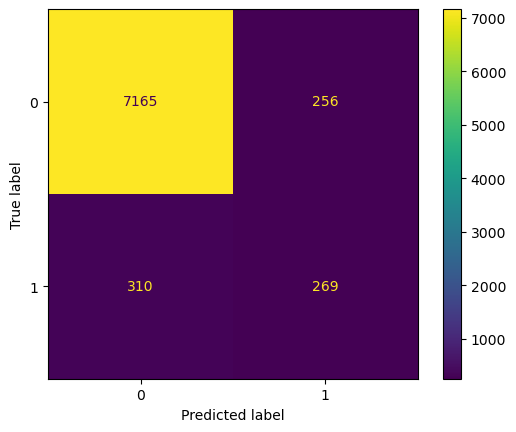

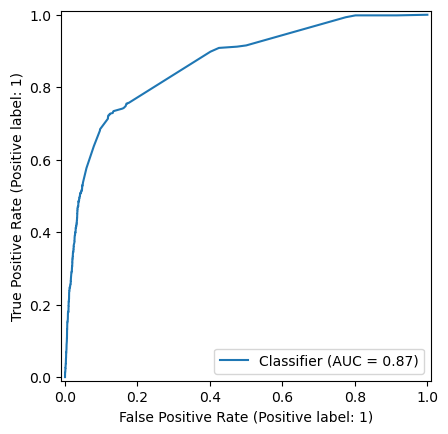

In [5]:
# import the data
data = pd.read_csv("data/processed/processed_data.csv")

# split into x and y data
x = data.select_dtypes(include='object')
y = data['target']

# split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

# identify numerical and categorical features
cat_features = x.select_dtypes(include='object').columns

# one hot encoding categories
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

# modelling pipeline
bag_pipe = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('classifier', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=random_state), random_state=random_state))
    ])

# parameter options to try
param_grid = {
    # smote hyperparameters
    'smote__sampling_strategy': [0.2, 0.5, 1.0],
    # decision tree hyperparameters
    'classifier__estimator__max_depth': [5, 10],
    'classifier__estimator__min_samples_split': [5, 10, 20],
    'classifier__estimator__min_samples_leaf': [2, 5, 10],
    'classifier__estimator__max_features': [0.8],
    'classifier__estimator__class_weight': [None, 'balanced'],
    # bagging classifier hyperparameters
    'classifier__n_estimators': [50],
    'classifier__max_samples': [0.8],
    'classifier__max_features': [1.0]
}

# create grid
grid = GridSearchCV(
    bag_pipe,
    param_grid,
    cv=4,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# fit the grid to the data, find the best model and its parameters
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
best_params = grid.best_params_

# make predictions using the best model
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# print the best parameters
print('Best Parameters:')
print(best_params)

# show classification report containing detailed metrics
print(classification_report(y_test, y_pred))

# show confusion matrix of predicted data vs actual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# display ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

In [75]:
result = permutation_importance(
    best_model,
    x_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'feature': x_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

feature_importance.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.xlabel('Mean decrease in F1 score')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.show()

          feature  importance       std
0  duration_group    0.282081  0.003819


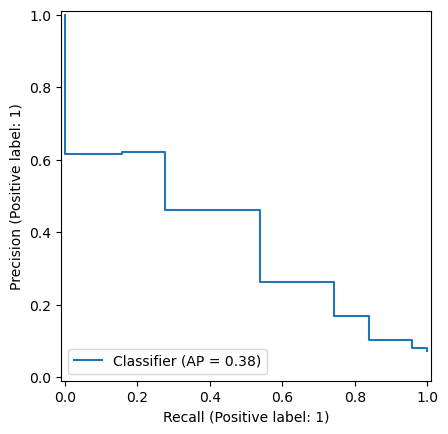

In [77]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba
)

In [84]:
feature_names = (
    grid
    .best_estimator_
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

feature_names

array(['cat__job_admin', 'cat__job_blue-collar', 'cat__job_entrepreneur',
       'cat__job_housemaid', 'cat__job_management', 'cat__job_retired',
       'cat__job_self-employed', 'cat__job_services', 'cat__job_student',
       'cat__job_technician', 'cat__job_unemployed', 'cat__job_unknown',
       'cat__marital_divorced', 'cat__marital_married',
       'cat__marital_single', 'cat__education_primary',
       'cat__education_secondary', 'cat__education_tertiary',
       'cat__education_unknown', 'cat__default_no', 'cat__default_yes',
       'cat__housing_no', 'cat__housing_yes', 'cat__loan_no',
       'cat__loan_yes', 'cat__contact_cellular', 'cat__contact_telephone',
       'cat__contact_unknown', 'cat__age_group_(0, 24]',
       'cat__age_group_(24, 34]', 'cat__age_group_(34, 45]',
       'cat__age_group_(45, 59]', 'cat__age_group_(59, 100]',
       'cat__balance_group_(-10000, 0]', 'cat__balance_group_(0, 100]',
       'cat__balance_group_(100, 200]', 'cat__balance_group_(1000, 3000]